<a href="https://colab.research.google.com/github/Sarah-0405/Cold_Spots_Bayern/blob/main/Cold_Spot_Weiterverarbeitung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Schritte und weitere Ziele:
- gdfs filtern nach ausschließlich Cold Spots jeder Stadt
- OSMnx Erreichbarkeitsanalysen
- Karte für jede Stadt, die Cold Spots genau und geometriegenau eingezeichnet hat, und die Einzugsgebiet eingezeichnet hat (vgl. cooler Stadtplan Münster https://geo.stadt-muenster.de/coolerstadtplan/)


zunächst: LST-Verteilung visualisieren für jede Stadt

In [ ]:
import geopandas as gpd

file_path = "/content/drive/MyDrive/Cold Spots Bayern/averaged_lst_per_pixel_per_city_allyears.geojson"
lst_data = gpd.read_file(file_path)
display(lst_data.head())

,city,avg_summer_LST_Celsius,geometry
0,Aschaffenburg,25.827932,POINT (9.23257 49.93527)
1,Aschaffenburg,25.828958,POINT (9.2355 49.935)
2,Aschaffenburg,25.846390,POINT (9.2355 49.93527)
3,Aschaffenburg,25.713771,POINT (9.23591 49.935)
4,Aschaffenburg,25.751711,POINT (9.23591 49.93527)


Found data for the following cities: ['Aschaffenburg' 'Augsburg' 'Bamberg' 'Bayreuth' 'Erlangen' 'Fürth'
 'Ingolstadt' 'Kempten (Allgäu)' 'Landshut' 'Munich' 'Nuremberg' 'Passau'
 'Regensburg' 'Rosenheim' 'Schweinfurt' 'Würzburg']
Created GeoDataFrame for Aschaffenburg with 69391 features.
Created GeoDataFrame for Augsburg with 164425 features.
Created GeoDataFrame for Bamberg with 121604 features.
Created GeoDataFrame for Bayreuth with 149925 features.
Created GeoDataFrame for Erlangen with 80705 features.
Created GeoDataFrame for Fürth with 60360 features.
Created GeoDataFrame for Ingolstadt with 150379 features.
Created GeoDataFrame for Kempten (Allgäu) with 67441 features.
Created GeoDataFrame for Landshut with 146398 features.
Created GeoDataFrame for Munich with 349956 features.
Created GeoDataFrame for Nuremberg with 209693 features.
Created GeoDataFrame for Passau with 77739 features.
Created GeoDataFrame for Regensburg with 172599 features.
Created GeoDataFrame for Rosenheim w

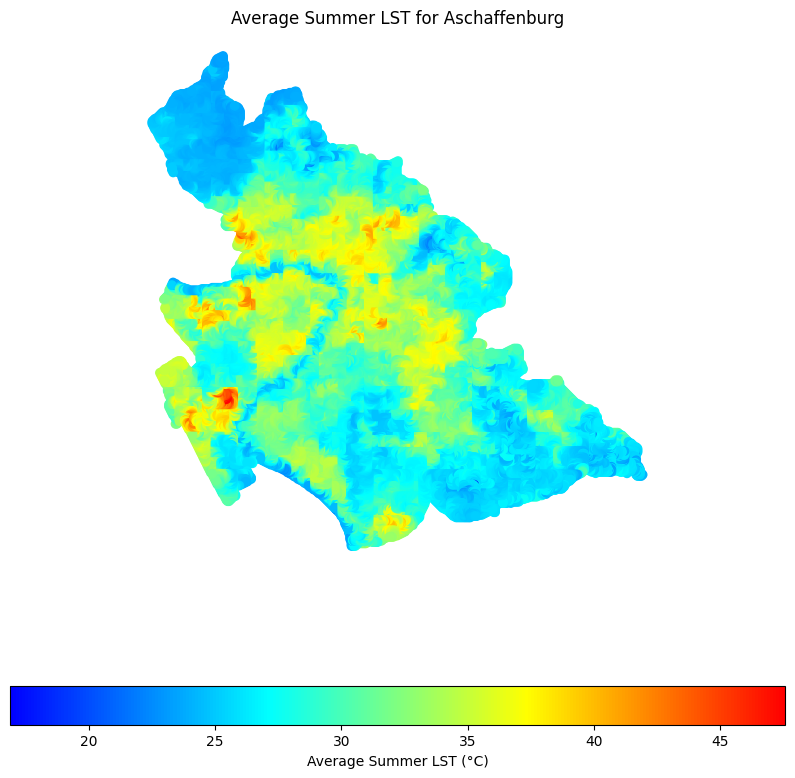

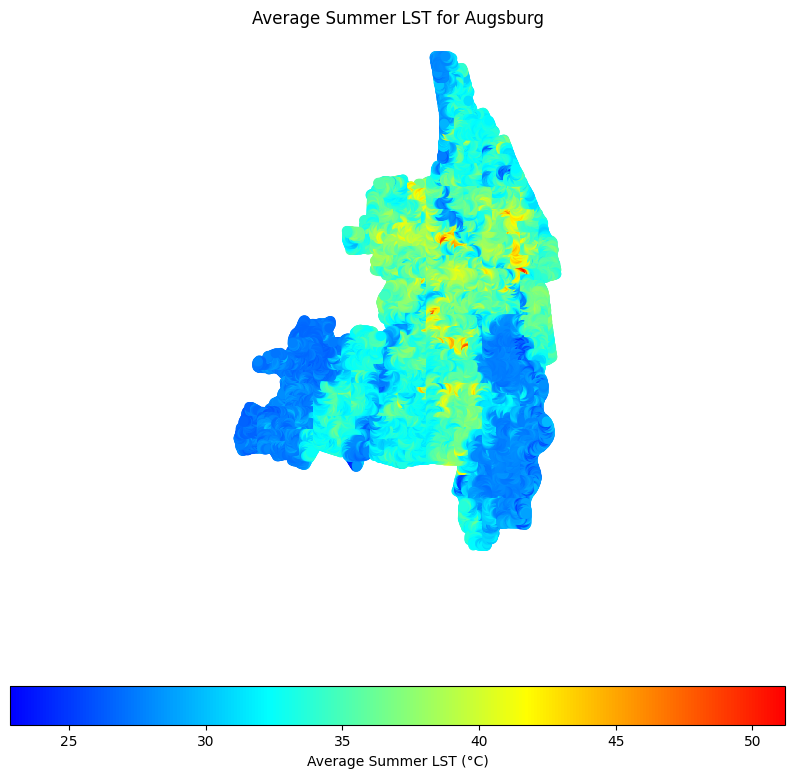

In [ ]:
# Step 2: Daten vorbereiten - Teile die Daten nach Städten auf

# Check unique cities
unique_cities = lst_data['city'].unique()
print(f"Found data for the following cities: {unique_cities}")

# Create a dictionary to hold GeoDataFrames for each city
city_lst_gdfs = {}
for city in unique_cities:
    city_lst_gdfs[city] = lst_data[lst_data['city'] == city].copy()
    print(f"Created GeoDataFrame for {city} with {len(city_lst_gdfs[city])} features.")

# Step 3: Visualisierung - Erstelle eine Karte für jede Stadt

import matplotlib.pyplot as plt

# Define a color map from blue (cold) to red (hot)
# We'll reverse the 'Reds' colormap and append it to the 'Blues' colormap
from matplotlib.colors import LinearSegmentedColormap
cmap_cold_hot = LinearSegmentedColormap.from_list("cold_to_hot", ["blue", "cyan", "yellow", "red"])


print("\nGenerating maps for each city...")

for city, gdf in city_lst_gdfs.items():
    if not gdf.empty:
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        # Plot the data, mapping 'avg_summer_LST_Celsius' to color
        # Use the custom colormap and add a colorbar
        gdf.plot(column='avg_summer_LST_Celsius', ax=ax, legend=True,
                 cmap=cmap_cold_hot,
                 legend_kwds={'label': "Average Summer LST (°C)",
                              'orientation': "horizontal"})

        ax.set_title(f'Average Summer LST for {city}')
        ax.set_axis_off()
        plt.show()
    else:
        print(f"No data to plot for {city}. Skipping map generation.")

# Step 4: Finish task - The maps are displayed after generation.
# You can add any final summary or notes here if needed.
print("\nMap generation complete.")


Cold Spot Ergebnisse liegen im Ordner gi_results_chunked

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import geopandas as gpd

folder_path = '/content/drive/MyDrive/Cold Spots Bayern/gi_results_chunked'
geojson_files = [f for f in os.listdir(folder_path) if f.endswith('.geojson')]

gdfs = {}
for file in geojson_files:
    file_path = os.path.join(folder_path, file)
    city_name = os.path.splitext(file)[0] # Extract city name from filename
    try:
        gdfs[city_name] = gpd.read_file(file_path)
        print(f"Successfully loaded {file}")
    except Exception as e:
        print(f"Error loading {file}: {e}")

print("\nLoaded GeoDataFrames:")
for city, gdf in gdfs.items():
    print(f"- {city}: {len(gdf)} features")

Successfully loaded Aschaffenburg_gi_results_chunked.geojson
Successfully loaded Augsburg_gi_results_chunked.geojson
Successfully loaded Bamberg_gi_results_chunked.geojson
Successfully loaded Bayreuth_gi_results_chunked.geojson
Successfully loaded Erlangen_gi_results_chunked.geojson
Successfully loaded Fürth_gi_results_chunked.geojson
Successfully loaded Ingolstadt_gi_results_chunked.geojson
Successfully loaded Kempten_(Allgäu)_gi_results_chunked.geojson
Successfully loaded Landshut_gi_results_chunked.geojson
Successfully loaded Munich_gi_results_chunked.geojson
Successfully loaded Nuremberg_gi_results_chunked.geojson
Successfully loaded Passau_gi_results_chunked.geojson
Successfully loaded Regensburg_gi_results_chunked.geojson
Successfully loaded Rosenheim_gi_results_chunked.geojson
Successfully loaded Schweinfurt_gi_results_chunked.geojson
Successfully loaded Würzburg_gi_results_chunked.geojson

Loaded GeoDataFrames:
- Aschaffenburg_gi_results_chunked: 69388 features
- Augsburg_gi

In [ ]:
print(gdfs['Würzburg_gi_results_chunked'].head())

       city  avg_summer_LST_Celsius  index_right  chunk_id   Gi_Star  \
0  Würzburg               30.380963         11.0      11.0  0.000205   
1  Würzburg               28.427906         11.0      11.0  0.000206   
2  Würzburg               32.586269         11.0      11.0  0.000206   
3  Würzburg               30.202087         11.0      11.0  0.000207   
4  Würzburg               28.828042         11.0      11.0  0.000208   

   Gi_Star_p_value        Gi_Star_sig                geometry  
0            0.011  Hot Spot (p<0.05)  POINT (562950 5518020)  
1            0.011  Hot Spot (p<0.05)  POINT (562920 5518020)  
2            0.011  Hot Spot (p<0.05)  POINT (562950 5518050)  
3            0.018  Hot Spot (p<0.05)  POINT (562920 5518050)  
4            0.023  Hot Spot (p<0.05)  POINT (562890 5518050)  


nach cold spots filtern für alle Städte ergibt, dass keine vorhanden sind => fehler beim erstellen der Cold Spots?



